In [2]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [3]:
import sys

sys.path.append('../scripts')

In [4]:
import numpy as np
import scanpy as sc
import pickle
import scvi

from cellina import CellinaModel
from utils import set_seed

/data/a330d/miniforge3/envs/cellina-reproduce/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Get dataset

In [3]:
set_seed(0)

In [4]:
adata = sc.read_h5ad("/data2/a330d/datasets/synthetic_spatial_adata_processed.h5ad")
#adata = sc.read("/data/a330d/projects/dsa/data/melanoma_cosmx_processed.h5ad")

In [5]:
seeds = range(5)

In [6]:
# Set holdout set for evaluation
fraction = 0.1
n_cells = adata.n_obs
n_holdout = int(n_cells * fraction)

# Randomly choose cells
holdout_idx = np.random.choice(n_cells, n_holdout, replace=False)

# Set 'is_holdout' to False by default, then True for selected cells
adata.obs['is_holdout'] = False
adata.obs.iloc[holdout_idx, adata.obs.columns.get_loc('is_holdout')] = True

In [7]:
adata_train = adata[~adata.obs["is_holdout"]].copy()

In [8]:
CellinaModel.setup_anndata(adata_train,
                           batch_key="batch",
                           labels_key='cell_type', 
                           domains_key='region', 
                           spatial_obsm_key="spatial_x",
                           layer='counts')

"""
CellinaModel.setup_anndata(adata,
                           batch_key="CPID_str",
                           labels_key='celltype', 
                           domains_key='BEST_RESPONSE_BY_SCAN', 
                           spatial_obsm_key="neighborhood_pseudobulks")
"""


INFO     Generating sequential column names                                                                        


'\nCellinaModel.setup_anndata(adata,\n                           batch_key="CPID_str",\n                           labels_key=\'celltype\', \n                           domains_key=\'BEST_RESPONSE_BY_SCAN\', \n                           spatial_obsm_key="neighborhood_pseudobulks")\n'

In [ ]:
model = CellinaModel(
            adata_train, n_latent=64, classifier_lambda=0., discriminator_lambda=0., 
            condition_on_intrinsic=False, use_observed_lib_size=True,
        )
model.train(
    max_epochs=30,
    check_val_every_n_epoch=1,
    early_stopping=True,
    early_stopping_patience=25,
    early_stopping_monitor="validation_loss",  # NOTE: z/e kl + reconstruction
    train_size=0.9,
    validation_size=0.1,
    #datasplitter_kwargs={
    #    "external_indexing": [train_idx, val_idx, test_idx],
    #},
    plan_kwargs={
        "lr": 0.0001,
        "weight_decay": 0.0001,
    },
    enable_checkpointing=True,
    batch_size=2048,
    devices=[1],
)

INFO     cellina: The Cellina model has been initialized                                                           


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/data/a330d/miniforge3/envs/cellina-reproduce/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.
/data/a330d/miniforge3/envs/cellina-reproduce/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.


Epoch 30/30: 100%|██████████| 30/30 [00:27<00:00,  1.08it/s, v_num=1, train_loss_step=1.39e+5, train_loss_epoch=1.42e+5]

`Trainer.fit` stopped: `max_epochs=30` reached.


Epoch 30/30: 100%|██████████| 30/30 [00:27<00:00,  1.08it/s, v_num=1, train_loss_step=1.39e+5, train_loss_epoch=1.42e+5]


<Axes: xlabel='epoch'>

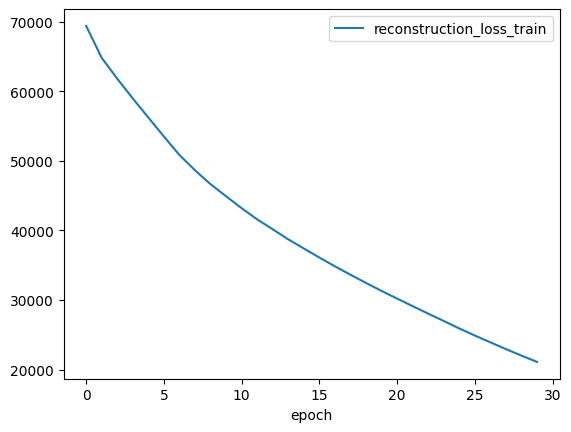

In [33]:
model.history_['reconstruction_loss_train'].plot()

<Axes: xlabel='epoch'>

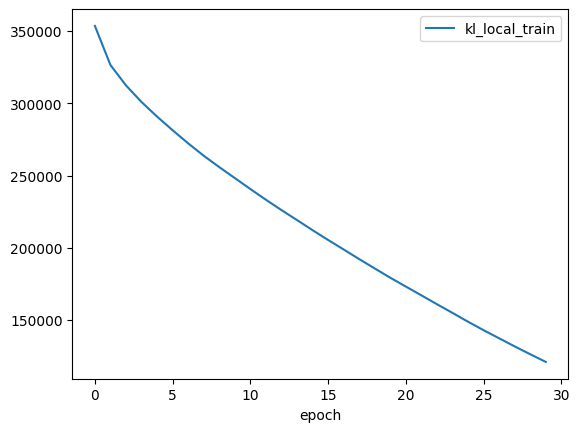

In [34]:
model.history_['kl_local_train'].plot()

In [7]:
# Conditions
is_fibro  = adata.obs["cell_type"].isin(["Fibroblast"])
is_myelo  = adata.obs["cell_type"].isin(["Myeloid"])
is_stress = adata.obs["region"] == "stressed"

# Combine for test set
test_mask = (is_stress) & (is_fibro | is_myelo)

In [8]:
test_idx = np.where(test_mask)[0]
trainval_idx = np.where(~test_mask)[0]

In [9]:
from sklearn.model_selection import train_test_split

train_idx, val_idx = train_test_split(
    trainval_idx,
    test_size=0.1,
    random_state=0,
    shuffle=True,
)

In [39]:
base_path = "/data2/a330d/data/cellina-reproducibility"

In [37]:
epochs = 100
conditions = [True, False]

In [35]:
for cond in conditions:
    for seed in seeds:
        set_seed(seed)
        model = CellinaModel(
            adata_train, n_latent=64, classifier_lambda=1e5, discriminator_lambda=5e5, 
            condition_on_intrinsic=cond
        )
        model.train(
            max_epochs=epochs,
            check_val_every_n_epoch=1,
            early_stopping=True,
            early_stopping_patience=25,
            early_stopping_monitor="validation_loss",  # NOTE: z/e kl + reconstruction
            train_size=0.9,
            validation_size=0.1,
            #datasplitter_kwargs={
            #    "external_indexing": [train_idx, val_idx, test_idx],
            #},
            plan_kwargs={
                "lr": 0.0001,
                "weight_decay": 0.0001,
            },
            enable_checkpointing=True,
            batch_size=2048,
            devices=[1],
        )

        model.save(f"{base_path}/trained/cond_z_{cond}_sim_seed_{seed}", overwrite=True)    

INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting                        


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
You are using a CUDA device ('NVIDIA GeForce RTX 4090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/data/a330d/miniforge3/envs/cellina/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.
/data/a330d/miniforge3/envs/cellina/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'val_dataloader' does not have many workers which may be

Epoch 100/100: 100%|██████████| 100/100 [01:44<00:00,  1.04s/it, v_num=1, train_loss=-4.93e+5]

`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 100/100: 100%|██████████| 100/100 [01:44<00:00,  1.05s/it, v_num=1, train_loss=-4.93e+5]
INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting                        


...

Epoch 100/100: 100%|██████████| 100/100 [01:43<00:00,  1.04s/it, v_num=1, train_loss=-4.84e+5]
INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting                        


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/data/a330d/miniforge3/envs/cellina/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.
/data/a330d/miniforge3/envs/cellina/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.


Epoch 100/100: 100%|██████████| 100/100 [01:44<00:00,  1.03s/it, v_num=1, train_loss=-4.86e+5]

`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 100/100: 100%|██████████| 100/100 [01:44<00:00,  1.05s/it, v_num=1, train_loss=-4.86e+5]


# SCVI baseline

In [17]:
scvi.model.SCVI.setup_anndata(adata_train, batch_key="batch", layer="counts")

In [18]:
model = scvi.model.SCVI(adata_train, n_latent=64, use_observed_lib_size=True)
model.train(
    max_epochs=30,
    plan_kwargs={
            "lr": 0.0001,
            "weight_decay": 0.0001,
    }
)

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
You are using a CUDA device ('NVIDIA GeForce RTX 4090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/data/a330d/miniforge3/envs/cellina-reproduce/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.


Epoch 30/30: 100%|██████████| 30/30 [00:56<00:00,  1.79s/it, v_num=1, train_loss_step=2.6e+3, train_loss_epoch=2.32e+3] 

`Trainer.fit` stopped: `max_epochs=30` reached.


Epoch 30/30: 100%|██████████| 30/30 [00:56<00:00,  1.88s/it, v_num=1, train_loss_step=2.6e+3, train_loss_epoch=2.32e+3]


<Axes: xlabel='epoch'>

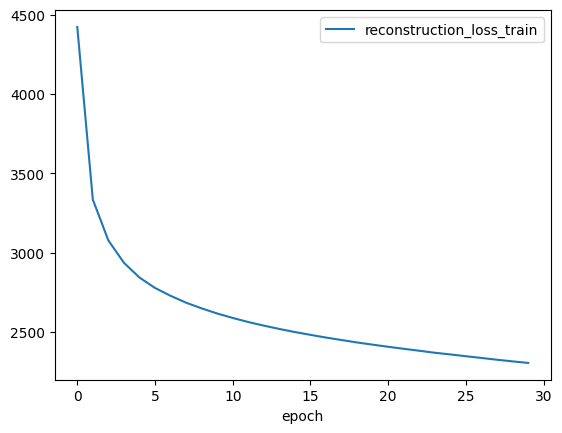

In [19]:
model.history_['reconstruction_loss_train'].plot()

<Axes: xlabel='epoch'>

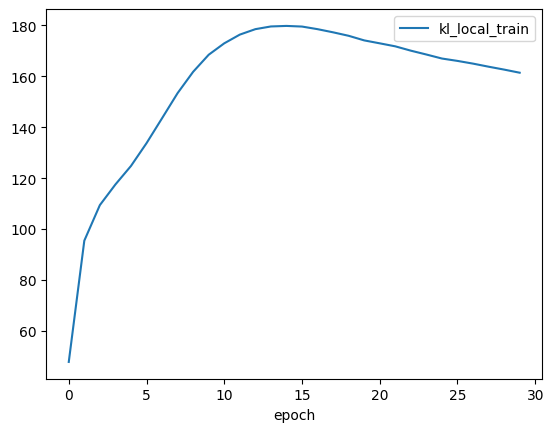

In [20]:
model.history_['kl_local_train'].plot()

In [ ]:
# Cellina
model.history_['kl_local_train']

,kl_local_train
epoch,
1,354286.625
2,325215.4375


In [43]:
# scvi
model.history_['kl_local_train']

,kl_local_train
epoch,
0,251313.296875
1,129610.6875
2,49812.683594


In [ ]:
# Train scvi per-seed and evaluate marginal log-likelihood on the same test_idx
epochs = 100
for seed in seeds:
    set_seed(seed)
    model = scvi.model.SCVI(adata, n_latent=64, use_observed_lib_size=False)
    model.train(
        max_epochs=epochs,
        plan_kwargs={
                "lr": 0.0001,
                "weight_decay": 0.0001,
        }
    )
    model.save(f"{base_path}/trained/scvi_liblatent_sim_seed_{seed}", overwrite=True)

# Evaluate Marginal LL via Importance Sampling to see holdout data fit

In [ ]:
results = {str(cond): [] for cond in conditions}
for cond in conditions:
    for seed in seeds:
        set_seed(seed)
        save_path = f"{base_path}/trained/cond_z_{cond}_sim_seed_{seed}"

        model = CellinaModel.load(save_path, adata_train, use_observed_lib_size=False)

        mll = model.get_marginal_ll(adata=adata[adata.obs['is_holdout']], 
                                    n_mc_samples=1000,
                                    return_mean=True)
        results[str(cond)].append(mll)

In [39]:
with open("results/mll_sim_results.pkl", "wb") as f:
    pickle.dump(results, f)

## scvi MLL

In [ ]:
scvi_results = []
for seed in seeds:
    set_seed(seed)
    save_path = f"{base_path}/trained/scvi_liblatent_sim_seed_{seed}"

    model = scvi.model.SCVI.load(save_path, adata)

    mll = model.get_marginal_ll(adata[adata.obs["is_holdout"]], n_mc_samples=1000, return_mean=True)
    scvi_results.append(mll)

In [47]:
# add scvi baseline to results and save
with open("results/mll_sim_results_scvi_liblatent.pkl", "wb") as f:
    pickle.dump(scvi_results, f)

# Plot

In [48]:
with open("results/mll_sim_results_scvi_liblatent.pkl", "rb") as f:
    scvi_results = pickle.load(f)

In [49]:
with open("results/mll_sim_results.pkl", "rb") as f:
    results = pickle.load(f)

In [50]:
results['scvi'] = scvi_results

/tmp/ipykernel_518795/2270828897.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


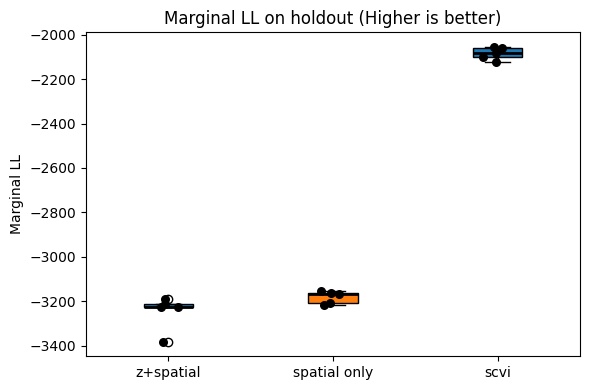

In [51]:
import matplotlib.pyplot as plt

conditions = list(results.keys())
data = [results[c] for c in conditions]

# Assign a color per condition
colors = ["tab:blue", "tab:orange"]   # add or change colors as needed
x_labels = ["z+spatial", "spatial only", "scvi"] # Rename labels for plotting

fig, ax = plt.subplots(figsize=(6, 4))

bp = ax.boxplot(
    data,
    patch_artist=True,   # allows facecolor
    labels=x_labels,
    medianprops=dict(color='black', linewidth=2)
)

# Apply colors to each box
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

# Optional: jittered points overlaid on the boxes
for i, cond in enumerate(conditions):
    y = np.array(results[cond])
    x = np.random.normal(i+1, 0.04, size=len(y))   # jitter for visibility
    ax.scatter(x, y, color="black", s=30, zorder=3)

ax.set_ylabel("Marginal LL")
ax.set_title("Marginal LL on holdout (Higher is better)")

plt.tight_layout()
plt.show()

/tmp/ipykernel_3482370/428128239.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


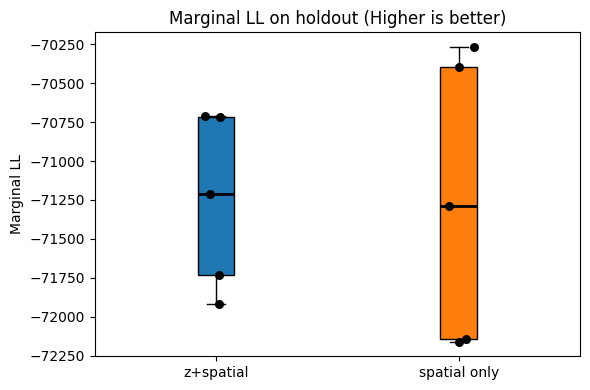

In [15]:
import matplotlib.pyplot as plt

conditions = list(results.keys())
data = [results[c] for c in conditions]

# Assign a color per condition
colors = ["tab:blue", "tab:orange"]   # add or change colors as needed
x_labels = ["z+spatial", "spatial only"] # Rename labels for plotting

fig, ax = plt.subplots(figsize=(6, 4))

bp = ax.boxplot(
    data,
    patch_artist=True,   # allows facecolor
    labels=x_labels,
    medianprops=dict(color='black', linewidth=2)
)

# Apply colors to each box
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

# Optional: jittered points overlaid on the boxes
for i, cond in enumerate(conditions):
    y = np.array(results[cond])
    x = np.random.normal(i+1, 0.04, size=len(y))   # jitter for visibility
    ax.scatter(x, y, color="black", s=30, zorder=3)

ax.set_ylabel("Marginal LL")
ax.set_title("Marginal LL on holdout (Higher is better)")

plt.tight_layout()
plt.show()

/tmp/ipykernel_240289/428128239.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


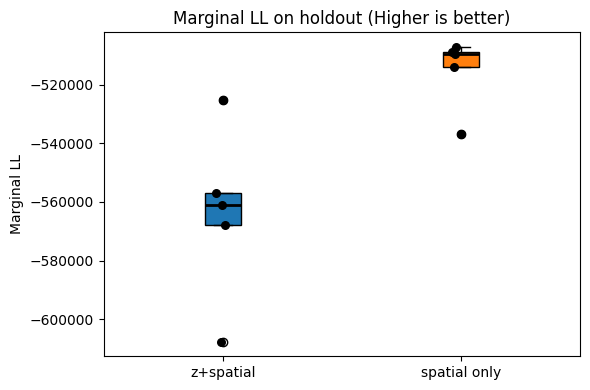

In [16]:
import matplotlib.pyplot as plt

conditions = list(results.keys())
data = [results[c] for c in conditions]

# Assign a color per condition
colors = ["tab:blue", "tab:orange"]   # add or change colors as needed
x_labels = ["z+spatial", "spatial only"] # Rename labels for plotting

fig, ax = plt.subplots(figsize=(6, 4))

bp = ax.boxplot(
    data,
    patch_artist=True,   # allows facecolor
    labels=x_labels,
    medianprops=dict(color='black', linewidth=2)
)

# Apply colors to each box
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

# Optional: jittered points overlaid on the boxes
for i, cond in enumerate(conditions):
    y = np.array(results[cond])
    x = np.random.normal(i+1, 0.04, size=len(y))   # jitter for visibility
    ax.scatter(x, y, color="black", s=30, zorder=3)

ax.set_ylabel("Marginal LL")
ax.set_title("Marginal LL on holdout (Higher is better)")

plt.tight_layout()
plt.show()